In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df = pd.read_csv('../deshimula_all_reviews_new.csv')
df.head()

,id,company_name,developer_role,date,title,content,upvote,downvote,comment_count,vibe
0,1,Betopia / BdCalling / Sparktech / Softvence / ...,NaN,"February 04, 2026",Behind the Noise: Freshers Get Real Wings Here...,I've been working at $parktech (under Betopi@ ...,1,14,8,Positive
1,2,Betopia / BdCalling / Sparktech / Softvence / ...,NaN,"January 11, 2026",My Personal Experience at Sp@rkTech Agency (Pa...,I have seen many negative comments about Betop...,1,24,20,Positive
2,3,Betopia / BdCalling / Sparktech / Softvence / ...,NaN,"January 10, 2026",Hard Work + Smart Work = Success,Betopi@ / BdCa11ing / $parktech / S0ftv3nce / ...,3,31,11,Positive
3,4,Betopia / BdCalling / Sparktech / Softvence / ...,NaN,"June 10, 2025",Good for freshers,Pros\nThis company is good for freshers who ha...,1,25,6,Positive
4,5,Betopia / BdCalling / Sparktech / Softvence / ...,NaN,"June 08, 2025",Supportive Work Environment with Strong Growth...,Pros:\nSupportive Management: Encouraging and ...,0,46,10,Positive


In [3]:
df.shape

(2552, 10)

In [4]:
NUM_SAMPLES = 2552


In [5]:
sentiment_df = df[['content', 'vibe']][:NUM_SAMPLES]
sentiment_df.shape, sentiment_df.head()

((2552, 2),
                                              content      vibe
 0  I've been working at $parktech (under Betopi@ ...  Positive
 1  I have seen many negative comments about Betop...  Positive
 2  Betopi@ / BdCa11ing / $parktech / S0ftv3nce / ...  Positive
 3  Pros\nThis company is good for freshers who ha...  Positive
 4  Pros:\nSupportive Management: Encouraging and ...  Positive)

In [6]:
X = sentiment_df['content']
y = sentiment_df['vibe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print(y_train.value_counts())

Training samples: 2041, Testing samples: 511
vibe
Negative    1584
Positive     231
Mixed        226
Name: count, dtype: int64


In [7]:
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    min_df=1,
    sublinear_tf=True,
    max_features=300_000,
)

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    token_pattern=r'(?u)\b\w+\b'
)

feature_union = FeatureUnion([
    ('char_tfidf', char_vectorizer),
    ('word_tfidf', word_vectorizer)
])

In [8]:
svc_pipeline = Pipeline([
    ('features', feature_union),
    ('classifier', SVC(kernel='rbf', C=1.0, random_state=42))
])

lgb_pipeline = Pipeline([
    ('features', feature_union),
    ('classifier', LGBMClassifier(random_state=42))
])

logistic_pipeline = Pipeline([
    ('features', feature_union),
    ('classifier', LogisticRegression(random_state=42))
])


In [9]:
svc_pipeline.fit(X_train, y_train)

,steps,"[('features', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('char_tfidf', ...), ('word_tfidf', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,input,'content'
,encoding,'utf-8'


In [10]:
lgb_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.815234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1264447
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 34502
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777


,steps,"[('features', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('char_tfidf', ...), ('word_tfidf', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,input,'content'
,encoding,'utf-8'


In [11]:
lgb_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.866233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1264447
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 34502
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777


,steps,"[('features', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('char_tfidf', ...), ('word_tfidf', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,input,'content'
,encoding,'utf-8'


In [12]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('features', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('char_tfidf', ...), ('word_tfidf', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,input,'content'
,encoding,'utf-8'


In [13]:
def evaluate(pipeline, name):
    preds = pipeline.predict(X_test)
    accuracy = np.mean(preds == y_test)
    macro_f1 = f1_score(y_test, preds, average='macro')
    print(f"{name} - Accuracy: {accuracy:.4f}, Macro F1 Score: {macro_f1:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    return preds

In [14]:
svc_preds = evaluate(svc_pipeline, "SVC")

SVC - Accuracy: 0.8082, Macro F1 Score: 0.4429
              precision    recall  f1-score   support

       Mixed       0.00      0.00      0.00        57
    Negative       0.81      1.00      0.89       396
    Positive       0.85      0.29      0.44        58

    accuracy                           0.81       511
   macro avg       0.55      0.43      0.44       511
weighted avg       0.72      0.81      0.74       511



In [15]:
lgb_preds = evaluate(lgb_pipeline, "LightGBM")

LightGBM - Accuracy: 0.8180, Macro F1 Score: 0.4894
              precision    recall  f1-score   support

       Mixed       0.50      0.04      0.07        57
    Negative       0.83      0.99      0.90       396
    Positive       0.73      0.38      0.50        58

    accuracy                           0.82       511
   macro avg       0.69      0.47      0.49       511
weighted avg       0.78      0.82      0.76       511



/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
logistic_preds = evaluate(logistic_pipeline, "Logistic Regression")

Logistic Regression - Accuracy: 0.8141, Macro F1 Score: 0.4603
              precision    recall  f1-score   support

       Mixed       0.00      0.00      0.00        57
    Negative       0.82      1.00      0.90       396
    Positive       0.80      0.34      0.48        58

    accuracy                           0.81       511
   macro avg       0.54      0.45      0.46       511
weighted avg       0.72      0.81      0.75       511



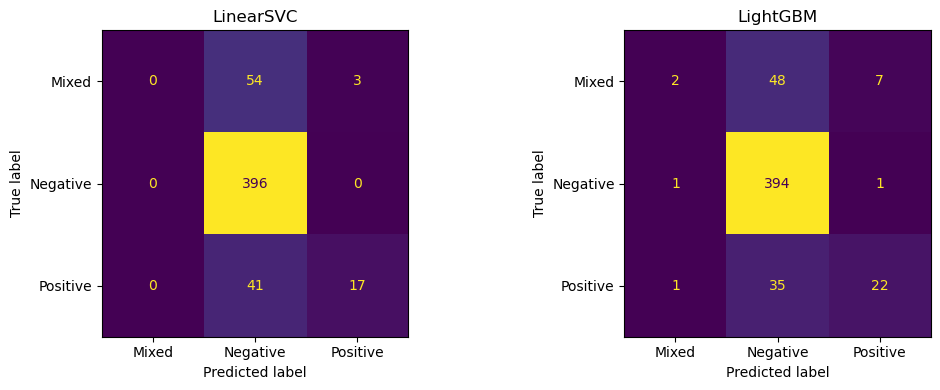

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, name in zip(axes, [svc_preds, lgb_preds], ["LinearSVC", "LightGBM"]):
    cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
    ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro']

svc_cv_results = cross_validate(svc_pipeline, X, y, cv=cv, scoring=scoring)
logistic_cv_results = cross_validate(logistic_pipeline, X, y, cv=cv, scoring=scoring)
lgb_cv_results = cross_validate(lgb_pipeline, X, y, cv=cv, scoring=scoring)

for name, results in [("SVC", svc_cv_results), ("Logistic Regression", logistic_cv_results), ("LightGBM", lgb_cv_results)]:
    print(f"{name}:")
    print(f"  Accuracy: {results['test_accuracy'].mean():.4f} (+/- {results['test_accuracy'].std():.4f})")
    print(f"  F1 Macro: {results['test_f1_macro'].mean():.4f} (+/- {results['test_f1_macro'].std():.4f})")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.702103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1269059
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 34732
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.725174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1272561
[LightGBM] [Info] Number of data points in the train set: 2041, number of used features: 34622
[LightGBM] [Info] Start training from score -2.200660
[LightGBM] [Info] Start training from score -0.253487
[LightGBM] [Info] Start training from score -2.178777


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.752988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1284114
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 35028
[LightGBM] [Info] Start training from score -2.196735
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.179267


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.729110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1284560
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 35100
[LightGBM] [Info] Start training from score -2.196735
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.179267


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.746738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1284338
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 34985
[LightGBM] [Info] Start training from score -2.201150
[LightGBM] [Info] Start training from score -0.253976
[LightGBM] [Info] Start training from score -2.174948
SVC:
  Accuracy: 0.8056 (+/- 0.0050)
  F1 Macro: 0.4318 (+/- 0.0176)
Logistic Regression:
  Accuracy: 0.8201 (+/- 0.0081)
  F1 Macro: 0.4790 (+/- 0.0251)
LightGBM:
  Accuracy: 0.8213 (+/- 0.0085)
  F1 Macro: 0.4961 (+/- 0.0293)


/home/kibria/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
